# Weighted Graph States with Sector Lengths
### Measurement, Cluster Extraction, and Machine Learning Ranking

**Goal:** Generate weighted graph states, measure some qubits, compute the sector lengths of the post-measurement state, and use machine learning to predict which protocols produce the best output states.

**What this notebook checks:**
- dataset quality,
- sector-length distributions,
- cluster-state extraction quality,
- ML prediction accuracy,
- and ML-ranked best protocols.


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os 
os.chdir(Path)
from mlandsectorlengths import (
    _apply_style,
    generate_protocol_dataset,
    train_sector_and_output_models,
    rank_protocols_with_ml,
    best_protocols_per_graph,
    fig_fidelity_hist,
    fig_sector_scatter,
    fig_top_protocols,
)

_apply_style()
OUT = "C:\\Users\\rfrantzesk\\Desktop\\startupideas\\probabilisticML\\nb_output_sector\\"
os.makedirs(OUT, exist_ok=True)
print("Environment ready.")

Environment ready.


In [17]:
df_tiny = generate_protocol_dataset(
    rows=2,
    cols=3,
    n_graph_samples=8,
    measured_k=3,
    protocols_per_subset=2,
    seed=0,
    n_jobs=-1,
)

display(df_tiny.head())
print("Shape:", df_tiny.shape)
print("Distinct subsets:", df_tiny['subset_label'].nunique())
print("Good-output fraction:", df_tiny['good_output'].mean())

Generating graph samples: 100%|██████████| 8/8 [00:00<00:00, 3638.52graph/s]

,sample_id,subset_label,success_probability,cluster_fidelity,sector_distance_to_cluster,A_1,A_2,A_3,phase_0,phase_dev_0,...,measured_qubit_0,meas_theta_0,meas_phi_0,measured_qubit_1,meas_theta_1,meas_phi_1,measured_qubit_2,meas_theta_2,meas_phi_2,good_output
0,0,0-1-2,0.099481,0.379983,2.897221,2.048645,3.0,1.951355,2.001074,1.140518,...,0,2.291781,5.126159,1,1.707848,0.017207,2,2.937617,5.387230,0
1,0,0-1-2,0.153257,0.073480,4.198412,2.968726,3.0,1.031274,2.001074,1.140518,...,0,0.105512,5.423513,1,2.292280,3.402101,2,0.551838,1.883145,0
2,0,0-1-3,0.087619,0.082099,2.361454,1.669800,3.0,2.330200,2.001074,1.140518,...,0,1.327911,4.213657,1,0.088969,4.066412,3,0.390447,3.866579,0
3,0,0-1-3,0.231879,0.208338,2.362195,1.670324,3.0,2.329676,2.001074,1.140518,...,0,1.205359,4.307387,1,3.132827,4.086956,3,3.081385,4.325638,0
4,0,0-1-4,0.034706,0.040480,2.365622,1.672748,3.0,2.327252,2.001074,1.140518,...,0,1.221833,3.300899,1,0.424418,1.949307,4,2.266622,3.052594,0


Shape: (320, 65)
Distinct subsets: 20
Good-output fraction: 0.1


## 2 — Generate the main dataset

In [19]:
df = generate_protocol_dataset(
    rows=2,
    cols=3,
    n_graph_samples=100,
    measured_k=3,
    protocols_per_subset=3,
    seed=42,
    n_jobs=-1,
)

df.to_csv(OUT + "graph_sector_dataset.csv", index=False)
print("Dataset shape:", df.shape)
display(df[["cluster_fidelity", "success_probability", "sector_distance_to_cluster", "A_1", "A_2", "A_3"]].describe())

Generating graph samples: 100%|██████████| 100/100 [00:01<00:00, 78.72graph/s]


Dataset shape: (6000, 65)


,cluster_fidelity,success_probability,sector_distance_to_cluster,A_1,A_2,A_3
count,6000.000000,6000.000000,6000.000000,6000.000000,6.000000e+03,6000.000000
mean,0.185568,0.124204,2.301541,1.627435,3.000000e+00,2.372565
std,0.149891,0.060458,1.018282,0.720034,1.065625e-15,0.720034
min,0.000022,0.002042,0.005230,0.003698,3.000000e+00,1.000445
25%,0.070980,0.081218,1.501117,1.061450,3.000000e+00,1.792799
50%,0.151954,0.119240,2.251644,1.592152,3.000000e+00,2.407848
75%,0.261057,0.160332,3.121454,2.207201,3.000000e+00,2.938550
max,0.939670,0.463315,4.242011,2.999555,3.000000e+00,3.996302


## 3 — Inspect outcome distributions

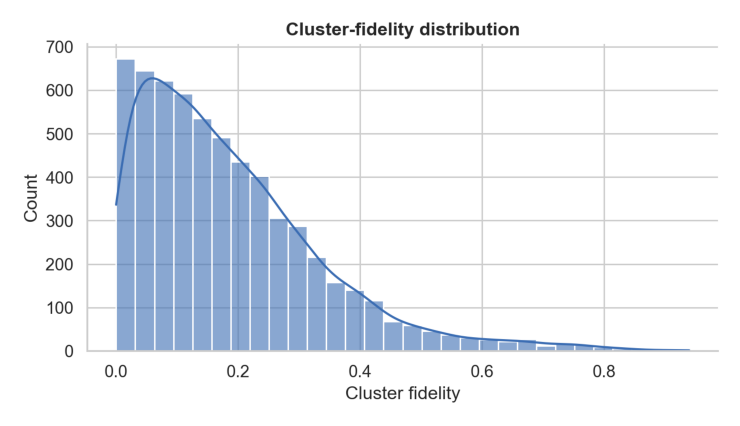

In [21]:
fig_fidelity_hist(df, OUT + "fig_cluster_fidelity_hist.png")
plt.figure(figsize=(8, 4))
plt.imshow(plt.imread(OUT + "fig_cluster_fidelity_hist.png"))
plt.axis("off")
plt.show()

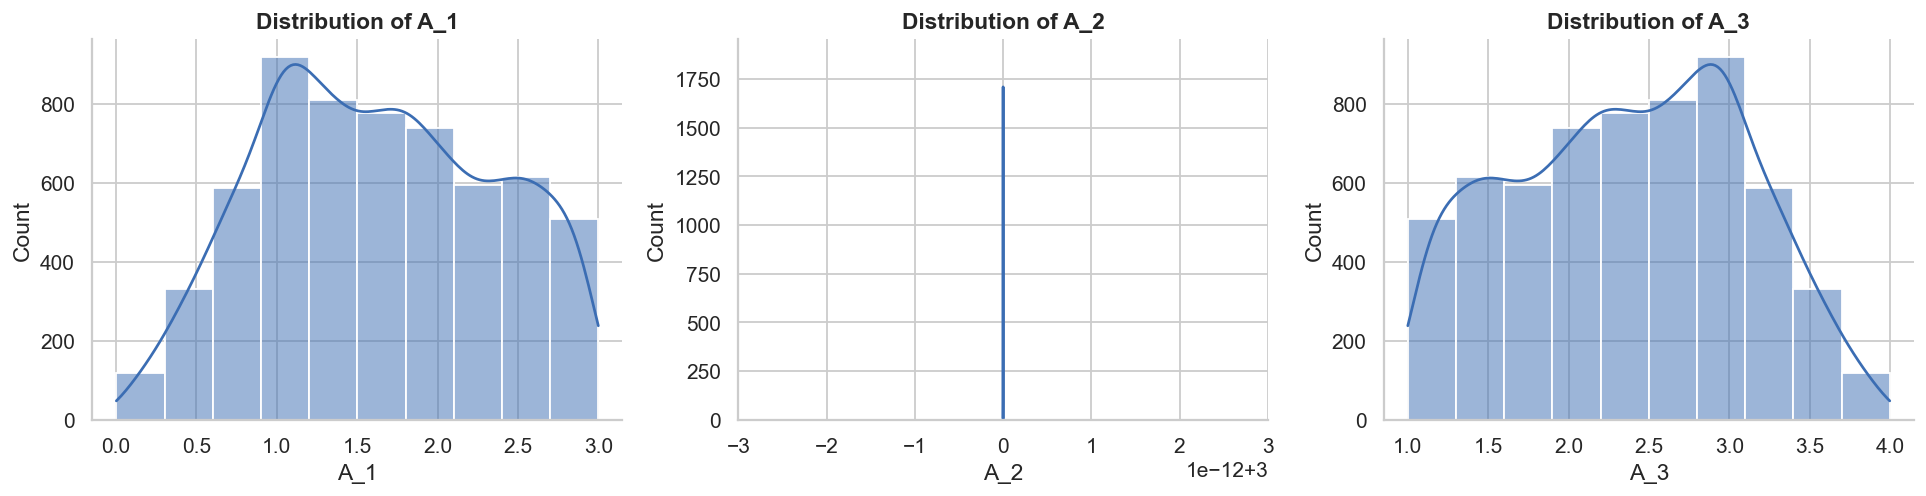

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["A_1", "A_2", "A_3"]):
    sns.histplot(df[col], bins=10, kde=True, ax=ax, color="#3B6DB3")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.savefig(OUT + "fig_sector_distributions.png", dpi=200)
plt.show()

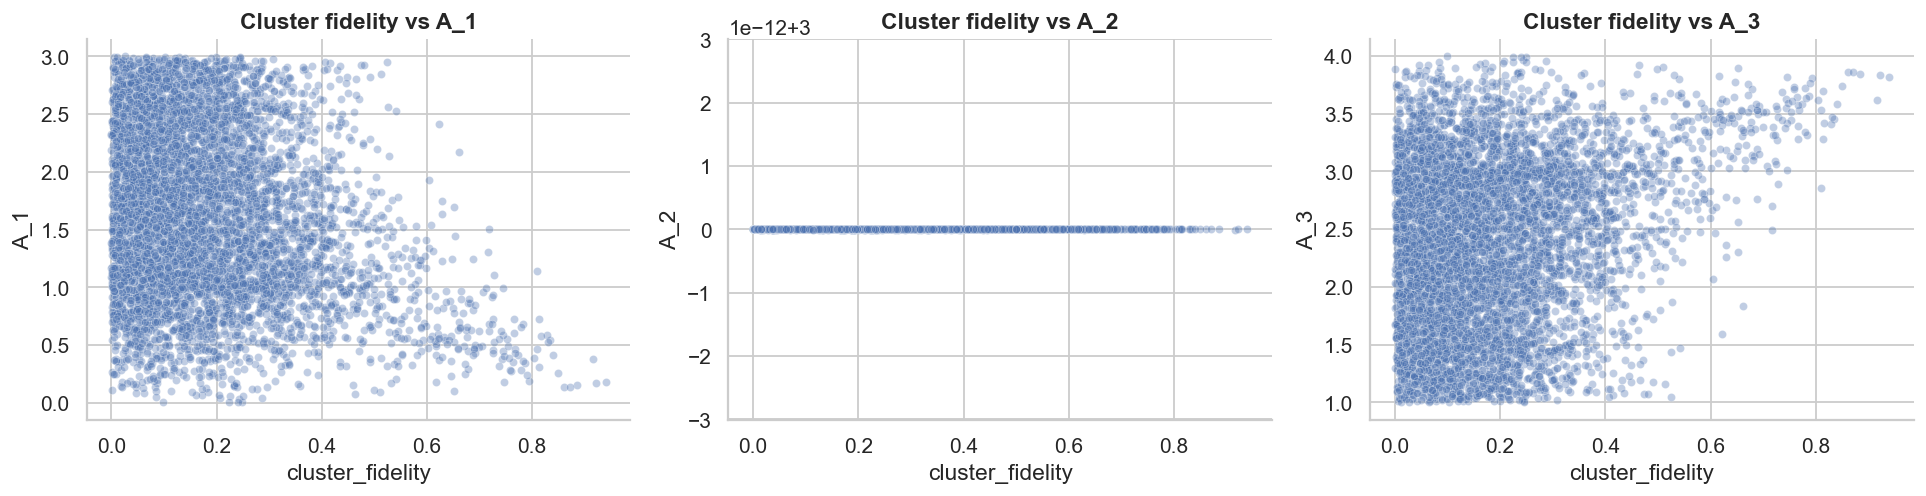

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.scatterplot(data=df, x="cluster_fidelity", y="A_1", alpha=0.35, s=20, ax=axes[0])
sns.scatterplot(data=df, x="cluster_fidelity", y="A_2", alpha=0.35, s=20, ax=axes[1])
sns.scatterplot(data=df, x="cluster_fidelity", y="A_3", alpha=0.35, s=20, ax=axes[2])
axes[0].set_title("Cluster fidelity vs A_1")
axes[1].set_title("Cluster fidelity vs A_2")
axes[2].set_title("Cluster fidelity vs A_3")
plt.tight_layout()
plt.savefig(OUT + "fig_fidelity_vs_sectors.png", dpi=200)
plt.show()

## 4 — Best raw protocols in the dataset

In [30]:
top_true = df.sort_values("cluster_fidelity", ascending=False).head(20)
display(top_true[[
    "sample_id",
    "subset_label",
    "cluster_fidelity",
    "success_probability",
    "sector_distance_to_cluster",
    "A_1", "A_2", "A_3"
]])

,sample_id,subset_label,cluster_fidelity,success_probability,sector_distance_to_cluster,A_1,A_2,A_3
3314,55,0-2-3,0.939670,0.201562,0.255696,0.180804,3.0,3.819196
2459,40,3-4-5,0.922441,0.163256,0.235386,0.166443,3.0,3.833557
2099,34,3-4-5,0.915739,0.184370,0.533916,0.377535,3.0,3.622465
1162,19,0-3-4,0.885094,0.217378,0.217116,0.153524,3.0,3.846476
4223,70,0-3-4,0.871286,0.084681,0.191231,0.135221,3.0,3.864779
2098,34,3-4-5,0.861100,0.137407,0.195264,0.138073,3.0,3.861927
3419,56,3-4-5,0.849461,0.017031,0.363489,0.257025,3.0,3.742975
3839,63,3-4-5,0.840012,0.192680,0.582321,0.411763,3.0,3.588237
51,0,2-3-5,0.834693,0.148208,0.772747,0.546414,3.0,3.453586
1077,17,3-4-5,0.830665,0.154310,0.743236,0.525547,3.0,3.474453


## 5 — Train machine learning models

In [31]:
M = train_sector_and_output_models(df)

sector_metrics_df = pd.DataFrame(M["sector_metrics"]).T.reset_index().rename(columns={"index": "sector"})
fid_metrics_df = pd.DataFrame([M["fid_metrics"]])
good_metrics_df = pd.DataFrame([M["good_metrics"]])

print("Sector regression metrics")
display(sector_metrics_df)

print("Fidelity regression metrics")
display(fid_metrics_df)

print("Good-output classification metrics")
display(good_metrics_df)

Sector regression metrics


,sector,mae,r2
0,A_1,4.664662e-01,0.388506
1,A_2,8.191966e-16,0.000604
2,A_3,4.664662e-01,0.388506


Fidelity regression metrics


,mae,r2
0,0.096669,0.255917


Good-output classification metrics


,accuracy,roc_auc
0,0.907333,0.758416


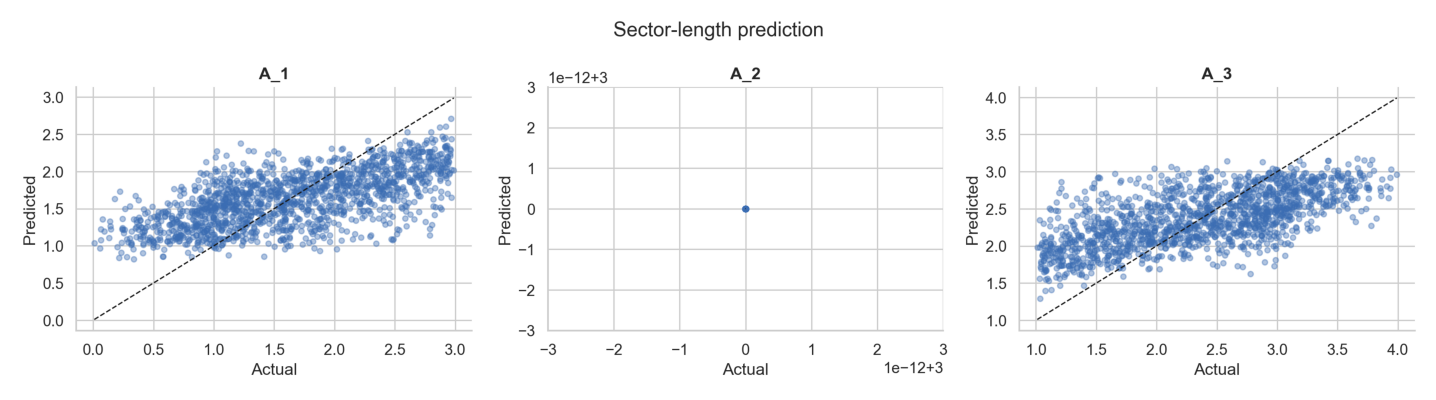

In [33]:
fig_sector_scatter(
    M["y_sector_te"],
    M["pred_sector"],
    M["y_sector_cols"],
    OUT + "fig_sector_prediction.png",
)
plt.figure(figsize=(14, 4))
plt.imshow(plt.imread(OUT + "fig_sector_prediction.png"))
plt.axis("off")
plt.show()

## 6 — Rank protocols with machine learning

In [34]:
scored = rank_protocols_with_ml(df, M)
scored.to_csv(OUT + "graph_sector_scored_protocols.csv", index=False)

display(scored[[
    "sample_id",
    "subset_label",
    "cluster_fidelity",
    "pred_cluster_fidelity",
    "pred_good_output_proba",
    "ml_score"
]].head(20))

,sample_id,subset_label,cluster_fidelity,pred_cluster_fidelity,pred_good_output_proba,ml_score
0,17,3-4-5,0.830665,0.727335,0.844311,0.768277
1,17,3-4-5,0.766346,0.693837,0.901007,0.766346
2,8,0-1-2,0.828569,0.646650,0.922410,0.743166
3,56,3-4-5,0.849461,0.707816,0.805874,0.742136
4,8,3-4-5,0.810202,0.657648,0.893229,0.740101
5,56,3-4-5,0.783203,0.678382,0.849246,0.738185
6,55,2-3-5,0.725992,0.660795,0.852394,0.727855
7,8,0-1-2,0.678975,0.617346,0.914222,0.721253
8,83,2-3-5,0.746176,0.640545,0.863259,0.718495
9,55,0-1-2,0.659478,0.619651,0.892419,0.715120


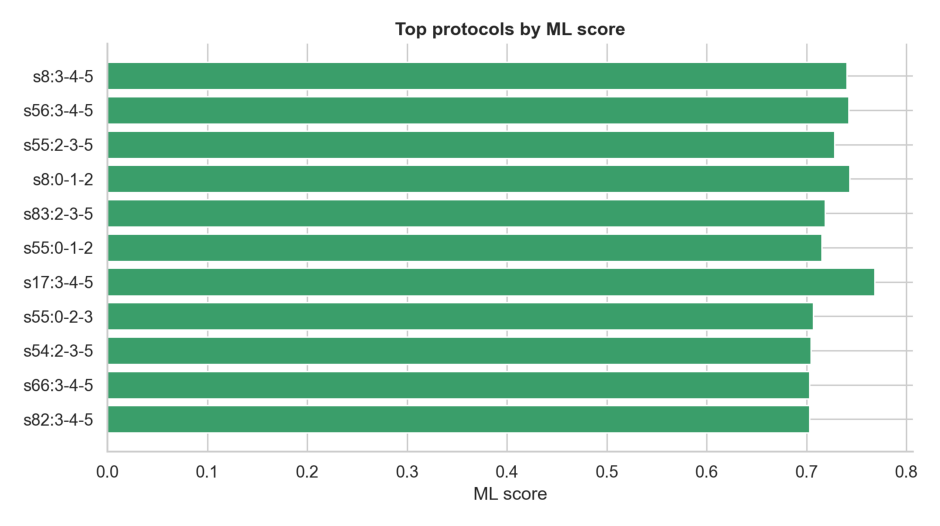

In [36]:
fig_top_protocols(scored, OUT + "fig_top_protocols.png")
plt.figure(figsize=(10, 5))
plt.imshow(plt.imread(OUT + "fig_top_protocols.png"))
plt.axis("off")
plt.show()

In [37]:
best_ml = best_protocols_per_graph(scored)
best_ml.to_csv(OUT + "graph_sector_best_protocols_per_graph.csv", index=False)

display(best_ml[[
    "sample_id",
    "subset_label",
    "cluster_fidelity",
    "pred_cluster_fidelity",
    "pred_good_output_proba",
    "ml_score",
    "A_1", "A_2", "A_3"
]].head(20))

,sample_id,subset_label,cluster_fidelity,pred_cluster_fidelity,pred_good_output_proba,ml_score,A_1,A_2,A_3
0,0,2-3-5,0.834693,0.608639,0.665874,0.628671,0.546414,3.0,3.453586
1,1,2-3-4,0.343385,0.292674,0.010795,0.194016,2.147626,3.0,1.852374
2,2,0-2-3,0.773096,0.593884,0.808666,0.669058,0.417154,3.0,3.582846
3,3,0-2-3,0.722937,0.558681,0.702429,0.608993,0.912366,3.0,3.087634
4,4,1-2-5,0.460455,0.342098,0.607468,0.434978,0.855475,3.0,3.144525
5,5,3-4-5,0.725196,0.522131,0.672740,0.574844,0.936290,3.0,3.063710
6,6,1-2-3,0.523940,0.432445,0.705601,0.528050,1.433334,3.0,2.566666
7,7,0-3-5,0.553153,0.400782,0.632086,0.481739,1.261421,3.0,2.738579
8,8,0-1-2,0.828569,0.646650,0.922410,0.743166,0.588412,3.0,3.411588
9,9,0-3-4,0.472324,0.340672,0.640296,0.445541,0.972644,3.0,3.027356


## 7 — Check how good ML ranking is

In [38]:
true_best = df.loc[df.groupby("sample_id")["cluster_fidelity"].idxmax()].copy()
true_best = true_best[["sample_id", "cluster_fidelity", "subset_label"]].rename(columns={
    "cluster_fidelity": "true_best_fidelity",
    "subset_label": "true_best_subset",
})

ml_best = best_ml[["sample_id", "cluster_fidelity", "subset_label", "pred_cluster_fidelity", "ml_score"]].rename(columns={
    "cluster_fidelity": "ml_selected_true_fidelity",
    "subset_label": "ml_selected_subset",
})

compare = true_best.merge(ml_best, on="sample_id", how="inner")
compare["subset_match"] = (compare["true_best_subset"] == compare["ml_selected_subset"]).astype(int)
compare["fidelity_gap"] = compare["true_best_fidelity"] - compare["ml_selected_true_fidelity"]

display(compare.head(20))
print("Subset match rate:", compare["subset_match"].mean())
print("Mean fidelity gap:", compare["fidelity_gap"].mean())
print("Median fidelity gap:", compare["fidelity_gap"].median())

,sample_id,true_best_fidelity,true_best_subset,ml_selected_true_fidelity,ml_selected_subset,pred_cluster_fidelity,ml_score,subset_match,fidelity_gap
0,0,0.834693,2-3-5,0.834693,2-3-5,0.608639,0.628671,1,0.000000
1,1,0.343385,2-3-4,0.343385,2-3-4,0.292674,0.194016,1,0.000000
2,2,0.773096,0-2-3,0.773096,0-2-3,0.593884,0.669058,1,0.000000
3,3,0.759647,0-1-2,0.722937,0-2-3,0.558681,0.608993,0,0.036711
4,4,0.460455,1-2-5,0.460455,1-2-5,0.342098,0.434978,1,0.000000
5,5,0.725196,3-4-5,0.725196,3-4-5,0.522131,0.574844,1,0.000000
6,6,0.535049,1-2-5,0.523940,1-2-3,0.432445,0.528050,0,0.011108
7,7,0.553153,0-3-5,0.553153,0-3-5,0.400782,0.481739,1,0.000000
8,8,0.828569,0-1-2,0.828569,0-1-2,0.646650,0.743166,1,0.000000
9,9,0.472324,0-3-4,0.472324,0-3-4,0.340672,0.445541,1,0.000000


Subset match rate: 0.72
Mean fidelity gap: 0.030885237405546127
Median fidelity gap: 0.0


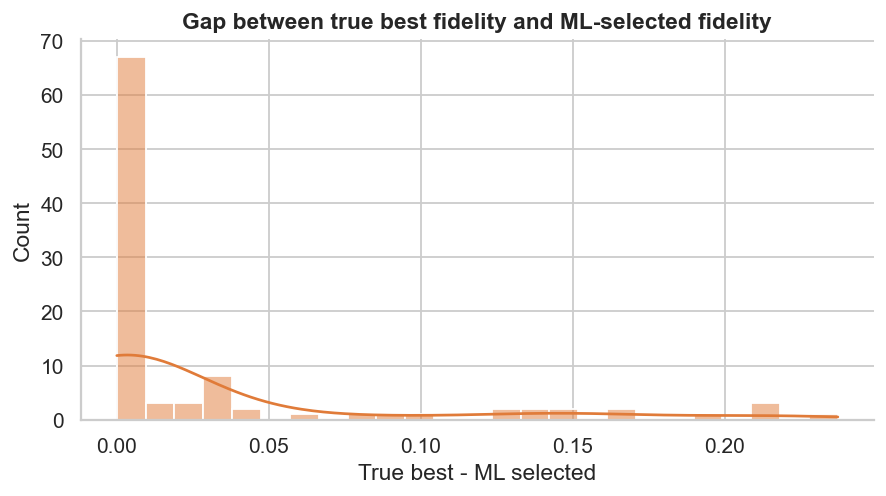

In [40]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(compare["fidelity_gap"], bins=25, kde=True, color="#E07B39", ax=ax)
ax.set_title("Gap between true best fidelity and ML-selected fidelity")
ax.set_xlabel("True best - ML selected")
plt.tight_layout()
plt.savefig(OUT + "fig_fidelity_gap.png", dpi=200)
plt.show()

## 8 — Sector-length pattern of the best outputs

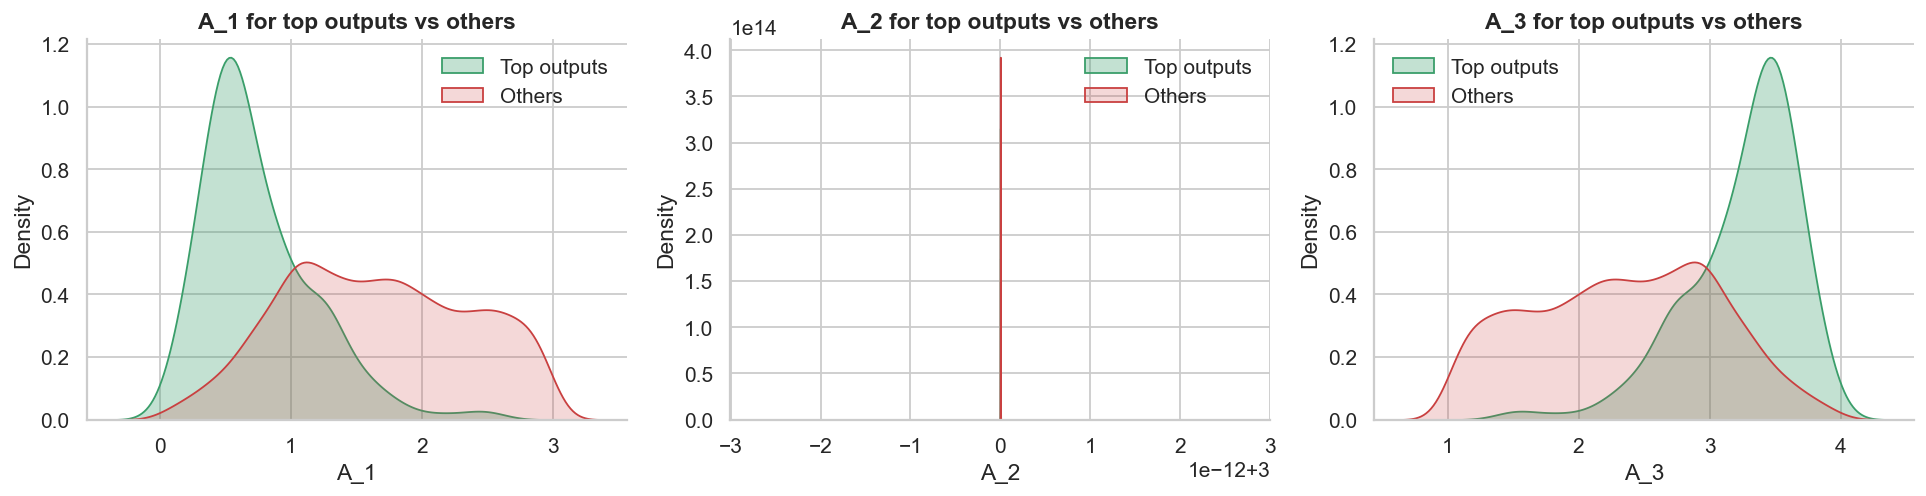

In [42]:
best_outputs = df.sort_values("cluster_fidelity", ascending=False).head(200).copy()
rest_outputs = df.sort_values("cluster_fidelity", ascending=False).iloc[200:].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["A_1", "A_2", "A_3"]):
    sns.kdeplot(best_outputs[col], ax=ax, label="Top outputs", color="#3A9E6A", fill=True, alpha=0.3)
    sns.kdeplot(rest_outputs[col], ax=ax, label="Others", color="#C94040", fill=True, alpha=0.2)
    ax.set_title(f"{col} for top outputs vs others")
    ax.legend()
plt.tight_layout()
plt.savefig(OUT + "fig_sector_top_vs_rest.png", dpi=200)
plt.show()